# Hand Built Pair Plot

This is a hand built pair plot using just matplotlib plotting functionality. Seaborn is imported just to load the data. This plot is generalizable so it can take any number of the numeric variables below. 

carat — weight of the diamond

cut — quality of the cut (Fair, Good, Very Good, Premium, Ideal)

color — diamond color grade (D = best, J = worst)

clarity — how clear the diamond is (e.g., IF, VVS1, VS2, SI1, etc.)

depth — total depth percentage = (z / mean(x, y)) × 100

table — width of top of diamond relative to widest point (%)

price — price in USD

x — length in mm

y — width in mm

z — depth (height) in mm

In [1]:
import numpy as np 
import pandas as pd
import matplotlib as mpl 
from matplotlib import pyplot as plt
from pandas import DataFrame 
import seaborn as sns 

In [2]:
diamonds = sns.load_dataset('diamonds')

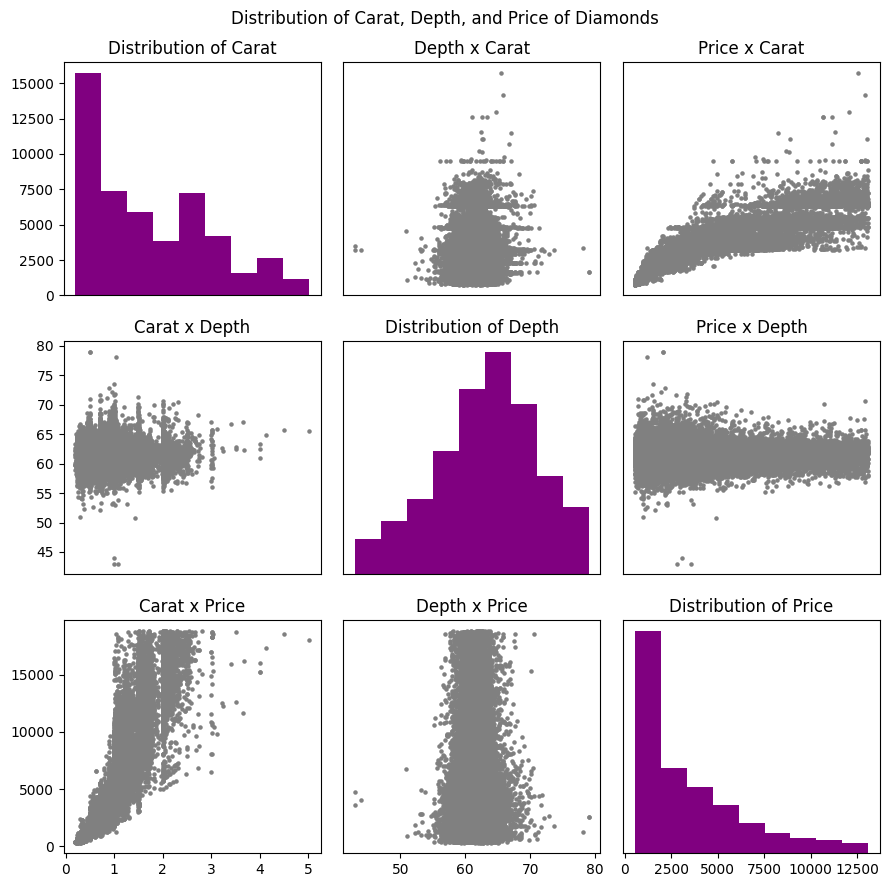

In [3]:
variables = ['carat', 'depth', 'price']
n = len(variables)

fig, axs = plt.subplots(n, n, figsize=(9, 9))
title = 'Distribution of '

for x in range(n):
    # build title
    ender = ', '
    if x == n-2: ender = ', and '
    if x == n-1: ender = ''
    title = title + variables[x].capitalize() + ender
    for y in range(n):
        if x == y: 
            # implement binning 
            var = diamonds[variables[x]]
            bins = np.linspace(var.quantile(0.05), var.quantile(0.95), 10)
            axs[x, y].hist(diamonds[variables[x]], color='purple', bins=bins)
            axs[x, y].set_title('Distribution of ' + variables[y].capitalize())
        else:
            axs[x, y].scatter(diamonds[variables[y]], diamonds[variables[x]], color='grey', s=5)
            axs[x, y].set_title(variables[y].capitalize() + ' x ' + variables[x].capitalize())
            
        if x != n-1:
            axs[x, y].tick_params(axis='x', bottom=False, labelbottom=False)
            
        if y != 0:
            axs[x, y].tick_params(axis='y', left=False, labelleft=False)
            
fig.suptitle(title + ' of Diamonds')
plt.tight_layout()
plt.show()